In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt

Use this part if you have all points coordinates

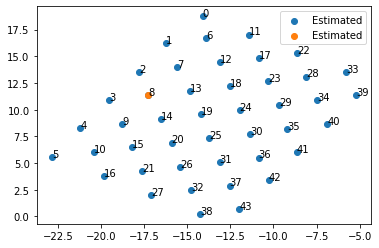

In [5]:
robot_coordinates = np.load("Matrices/forward_coordinates_2010-04-27_(1, 52, 11).npy")

# Separate the x, y, and z coordinates
x_coords, y_coords, z_coords = zip(*robot_coordinates)

# Create a 2D plot for x and y coordinates
# plt.scatter(new_grid[:, 0], new_grid[:, 1], label='Grid')
plt.scatter(x_coords, y_coords, label='Estimated')
plt.scatter(x_coords[8], y_coords[8], label='Estimated')
for i in range (len(x_coords)):
    plt.text(x_coords[i], y_coords[i], str(i))
plt.legend()
plt.show()

np.save('Matrices/robot_coord_new',robot_coordinates)

Use this part if you only have corner points

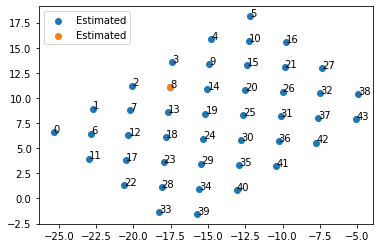

In [2]:
# Define the corners
corners = [[-25.33,6.64,-72.853], [-18.26,-1.38,-72.728], [-12.15,18.13,-72.692], [-4.93,10.39,-72.78]]
grid_size = (8, 11)

# Create a 2D array of points within the parallelogram
points = []

for i in range(grid_size[0]):
    for j in range(grid_size[1]):

        if bool(i%2) ^ bool(j%2):
            continue

        x_frac = j / (grid_size[1] - 1)
        y_frac = i / (grid_size[0] - 2)

        x = (1 - x_frac) * (1 - y_frac) * corners[0][0] + x_frac * (1 - y_frac) * corners[2][0] + (1 - x_frac) * y_frac * corners[1][0] + x_frac * y_frac * corners[3][0]
        y = (1 - x_frac) * (1 - y_frac) * corners[0][1] + x_frac * (1 - y_frac) * corners[2][1] + (1 - x_frac) * y_frac * corners[1][1] + x_frac * y_frac * corners[3][1]
        z = 0

        points.append((x, y, z))

# Separate the x, y, and z coordinates
x_coords, y_coords, z_coords = zip(*points)

# Create a 2D plot for x and y coordinates
# plt.scatter(new_grid[:, 0], new_grid[:, 1], label='Grid')
plt.scatter(x_coords, y_coords, label='Estimated')
plt.scatter(x_coords[8], y_coords[8], label='Estimated')
for i in range (len(x_coords)):
    plt.text(x_coords[i], y_coords[i], str(i))
plt.legend()
plt.show()

np.save('robot_coord_new',points)

load all datas:


In [6]:
from glob import glob

path_names = glob("Camera saved images and coordinates/robot_x_0.00_y_0.00_minus*.npy")
path_names
for path_name in path_names:
    cam_coord = np.load(path_name,allow_pickle=True)
    x,y,z = float(path_name.split("_")[2]),float(path_name.split("_")[4]),float(path_name.split("minus")[1].split("_")[0])
    x,y,z = int(x),int(y),int(z)
    zero = np.zeros((len(cam_coord),3))
    zero[:,:2] = cam_coord[:,:2]
    zero[:,2] = -z
    print(f'cam_coord_{x}_{y}_m{z}')
    globals()[f'cam_coord_{x}_{y}_m{z}'] = zero

cam_coord_0_0_m37
cam_coord_0_0_m40
cam_coord_0_0_m43
cam_coord_0_0_m46
cam_coord_0_0_m49
cam_coord_0_0_m52
cam_coord_0_0_m55
cam_coord_0_0_m58
cam_coord_0_0_m61


In [7]:
cam_coord_0_0_m37 = cam_coord_0_0_m37
cam_coord_0_0_m40 = cam_coord_0_0_m40
cam_coord_0_0_m43 = cam_coord_0_0_m43
cam_coord_0_0_m46 = cam_coord_0_0_m46
cam_coord_0_0_m49 = cam_coord_0_0_m49
cam_coord_0_0_m52 = cam_coord_0_0_m52
cam_coord_0_0_m55 = cam_coord_0_0_m55
cam_coord_0_0_m58 = cam_coord_0_0_m58
cam_coord_0_0_m61 = cam_coord_0_0_m61

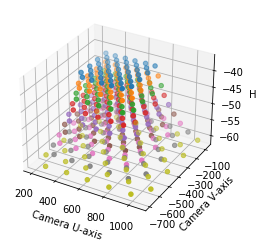

In [8]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

for cam_coord in   [cam_coord_0_0_m37,
                    cam_coord_0_0_m40,
                    cam_coord_0_0_m43,
                    cam_coord_0_0_m46,
                    cam_coord_0_0_m49,
                    cam_coord_0_0_m52,
                    cam_coord_0_0_m55,
                    cam_coord_0_0_m58,
                    cam_coord_0_0_m61]:
    x_coords_cam, y_coords_cam, z_coords_cam = zip(*cam_coord)
    x_coords_cam, y_coords_cam, z_coords_cam = np.array(x_coords_cam), np.array(y_coords_cam), np.array(z_coords_cam) 

    ax.scatter(x_coords_cam, -y_coords_cam, z_coords_cam, label='Estimated')
    # plt.scatter(x_coords_cam[1], -y_coords_cam[1], label='Estimated')
    # for i in range (len(x_coords_cam)):
    #     ax.text(x_coords_cam[i], -y_coords_cam[i], str(i), None)
    # plt.scatter(450, -80, label='Estimated')
    # plt.legend()



from matplotlib.font_manager import FontProperties

font = FontProperties()
font.set_family('serif')
font.set_name('Times New Roman')

import matplotlib.font_manager 
font = FontProperties()
font.set_family('serif')
font.set_name('Times New Roman')
font.set_size('xx-large')
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Times New Roman'




ax.set_xlabel('Camera U-axis')
ax.set_ylabel('Camera V-axis')
ax.set_zlabel('H')
# fig.savefig('.\\dataset.eps',format='eps')

plt.show()

cam_coord_0_0_m37_sorted,
cam_coord_0_0_m40_sorted,
cam_coord_0_0_m43_sorted,
cam_coord_0_0_m46_sorted,
cam_coord_0_0_m49_sorted,
cam_coord_0_0_m52_sorted,
cam_coord_0_0_m55_sorted,
cam_coord_0_0_m58_sorted,
cam_coord_0_0_m61_sorted,


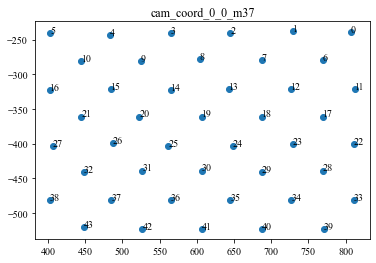

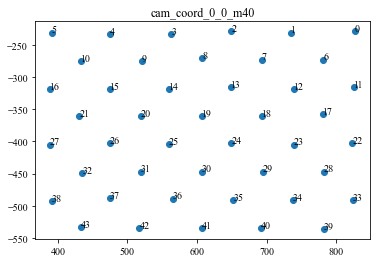

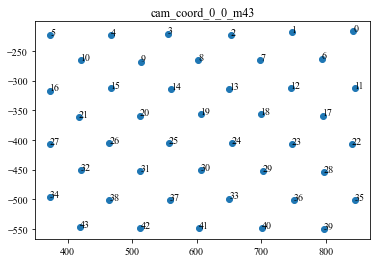

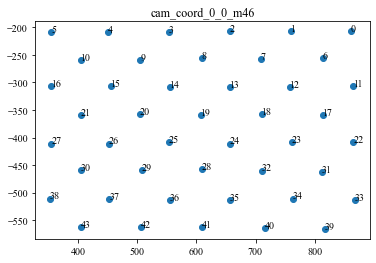

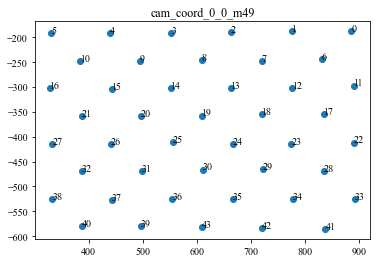

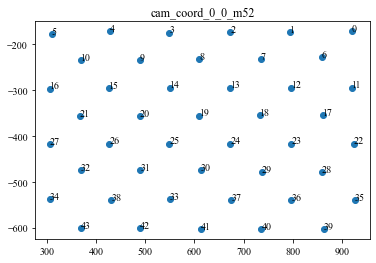

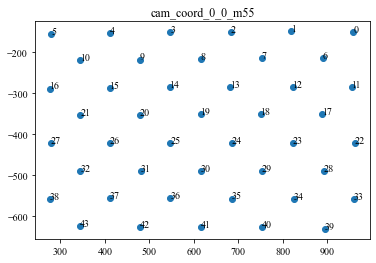

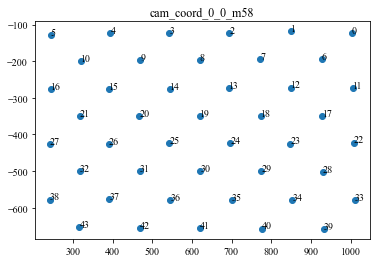

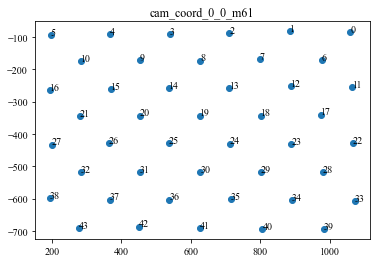

In [13]:
cam_coordsss = [cam_coord_0_0_m37,
cam_coord_0_0_m40,
cam_coord_0_0_m43,
cam_coord_0_0_m46,
cam_coord_0_0_m49,
cam_coord_0_0_m52,
cam_coord_0_0_m55,
cam_coord_0_0_m58,
cam_coord_0_0_m61]
# for j , cam_coord in enumerate([cam_coord_0_0_m37,cam_coord_0_0_m40,cam_coord_0_0_m43,cam_coord_0_0_m46,cam_coord_0_0_m49]):
for j , cam_coord in enumerate(cam_coordsss):

    pts = np.array(cam_coord)   # shape (N,2)

    tol = 40  # adjust according to your row spacing

    # Create row labels
    row_labels = np.round(pts[:, 1] / tol).astype(int)

    sorted_pts = []

    for r in np.unique(row_labels):
        row = pts[row_labels == r]

        # Sort from right to left (largest x first)
        row = row[np.argsort(-row[:, 0])]

        sorted_pts.extend(row)

    sorted_pts = np.array(sorted_pts)

    print(f'cam_coord_0_0_m{37+3*j}_sorted,')
    globals()[f'cam_coord_0_0_m{37+3*j}_sorted'] = sorted_pts

    x_coords_cam, y_coords_cam, _ = zip(*sorted_pts)
    # x_coords_cam, y_coords_cam, _ = zip(*cam_coordsss[j])
    x_coords_cam, y_coords_cam = np.array(x_coords_cam), np.array(y_coords_cam)
    fig, ax = plt.subplots()
    ax.set_title(f'cam_coord_0_0_m{37+3*j}')

    ax.scatter(x_coords_cam, -y_coords_cam, label='Estimated')
    for i in range (len(x_coords_cam)):
        ax.text(x_coords_cam[i], -y_coords_cam[i], str(i), None)

plt.show()


In [10]:
print("[",end="")
for i in range(44):
    print(f"{i},",end="")
print("]",end="")

[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,]

Pleaaaase Check the orders and if it is not in order currect it:


In [14]:
ord_43 = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,35,36,33,37,38,34,39,40,41,42,43]
ord_46 = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,31,32,28,29,30,33,34,35,36,37,38,39,40,41,42,43]
ord_49 = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,41,42,43,39,40]
ord_52 = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,35,36,37,33,38,34,39,40,41,42,43]

In [15]:
cam_coord_0_0_m37_sorted = cam_coord_0_0_m37_sorted
cam_coord_0_0_m40_sorted = cam_coord_0_0_m40_sorted
cam_coord_0_0_m43_sorted = cam_coord_0_0_m43_sorted[ord_43]
cam_coord_0_0_m46_sorted = cam_coord_0_0_m46_sorted[ord_46]
cam_coord_0_0_m49_sorted = cam_coord_0_0_m49_sorted[ord_49]
cam_coord_0_0_m52_sorted = cam_coord_0_0_m52_sorted[ord_52]
cam_coord_0_0_m55_sorted = cam_coord_0_0_m55_sorted
cam_coord_0_0_m58_sorted = cam_coord_0_0_m58_sorted
cam_coord_0_0_m61_sorted = cam_coord_0_0_m61_sorted

for i in range(37,64,3):
    # print(i)
    np.save(f'camera robot coordinates sorted\circles_pixel_0_0_m{i}_sorted',globals()[f'cam_coord_0_0_m{i}_sorted'])


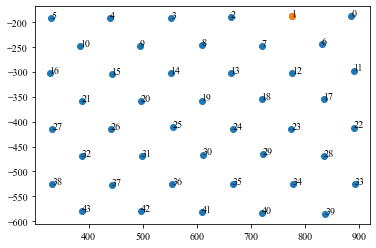

In [16]:
x_coords_cam, y_coords_cam, _ = zip(*cam_coord_0_0_m49_sorted)
x_coords_cam, y_coords_cam = np.array(x_coords_cam), np.array(y_coords_cam) 

plt.scatter(x_coords_cam, -y_coords_cam, label='Estimated')
plt.scatter(x_coords_cam[1], -y_coords_cam[1], label='Estimated')
for i in range (len(x_coords_cam)):
    plt.text(x_coords_cam[i], -y_coords_cam[i], str(i))
# plt.scatter(450, -80, label='Estimated')
# plt.legend()
plt.show()